# Aula 08 — Seleção de Características: Exercícios Práticos
**Disciplina:** Inteligência Artificial para Engenheiros — UFRGS  
**Prof.:** Vinicius Horn Cene

**Dataset principal:** Breast Cancer Wisconsin (569 amostras, 30 features, 2 classes)  
**Datasets auxiliares:** sintéticos para demonstrações específicas

| Seção | Tópico da aula | Exercício |
|-------|---------------|----------|
| 8.1 | Itens 1 — Por que selecionar? + Maldição da dimensionalidade | Demonstração experimental |
| 8.2 | Item 2 — Os três pilares | Generalização, interpretabilidade, eficiência |
| 8.3 | Item 3 — Tipos de métodos | Filter vs Wrapper vs Embedded |
| 8.4 | Item 4 — Regularização | L1 vs L2 vs Elastic Net |
| 8.5 | Item 5 — Permutation Importance | MDI vs Permutation |
| 8.6 | Item 6 — Instabilidade | Diferentes splits → diferentes subconjuntos |
| 8.7 | Item 7 — Stability Selection | Bootstrap + frequência de seleção |
| 8.8 | Item 8 — Multicolinearidade | Lasso vs ElasticNet com features correlacionadas |
| 8.9 | Item 9 — Data Leakage | Medir o viés silencioso |
| 8.10 | Item 10 — Pipeline correto | Protocolo sem leakage |

> **Convenção:** `[Objetivo + Racional + Risco] → [código com experimento] → [Conclusão]`


---
## Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.linear_model import (
    LogisticRegression, Lasso, LassoCV, Ridge, RidgeCV, ElasticNetCV
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif,
    mutual_info_classif, chi2, RFE, RFECV, SelectFromModel
)
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
C = {'blue':'#156082','navy':'#0E2841','orange':'#E97132',
     'green':'#196B24','teal':'#0F9ED5','red':'#C0392B','gray':'#888888'}

# ── Dataset principal: Breast Cancer ────────────────────────────────────
bc    = load_breast_cancer()
X_bc  = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc  = bc.target

cv5   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Breast Cancer: {X_bc.shape[0]} amostras, {X_bc.shape[1]} features')
print(f'Classes: {bc.target_names}  | distribuicao: {np.bincount(y_bc)}')
X_bc.describe().round(2).iloc[:, :6]


Breast Cancer: 569 amostras, 30 features
Classes: ['malignant' 'benign']  | distribuicao: [212 357]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
count,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10
std,3.52,4.30,24.30,351.91,0.01,0.05
min,6.98,9.71,43.79,143.50,0.05,0.02
25%,11.70,16.17,75.17,420.30,0.09,0.06
50%,13.37,18.84,86.24,551.10,0.10,0.09
75%,15.78,21.80,104.10,782.70,0.11,0.13
max,28.11,39.28,188.50,2501.00,0.16,0.35


---
## 8.1 Por que Selecionar? + Maldição da Dimensionalidade (Item 1)

**Objetivo:** demonstrar experimentalmente que adicionar features irrelevantes
degrada a performance — e que a degradação piora exponencialmente com p.

**Racional:** o modelo aprende padrões espúrios nas features de ruído.
Com p crescente, o espaço de hipóteses cresce e o modelo precisa de
exponencialmente mais dados para generalizar bem.

**Risco:** em datasets pequenos o efeito é dramático; em datasets grandes
pode ser sutil mas se manifesta em custo computacional e overfitting.


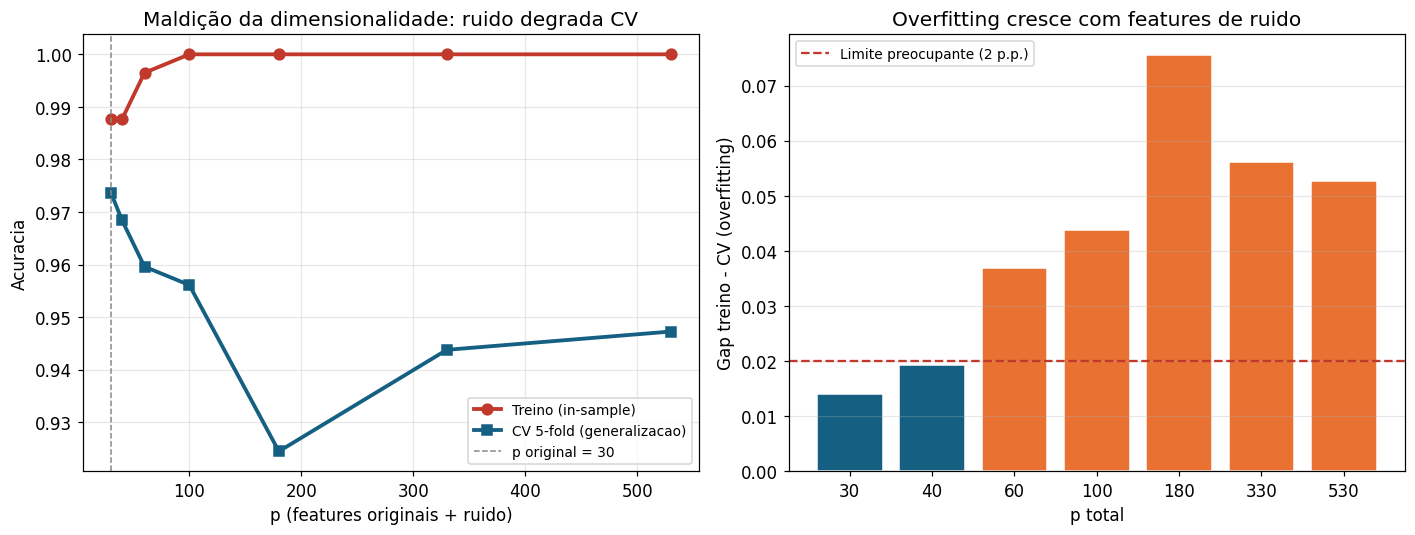

 p_total  acc_treino  acc_cv    gap
      30      0.9877  0.9737 0.0140
      40      0.9877  0.9684 0.0193
      60      0.9965  0.9596 0.0369
     100      1.0000  0.9561 0.0439
     180      1.0000  0.9245 0.0755
     330      1.0000  0.9438 0.0562
     530      1.0000  0.9473 0.0527


In [2]:
# ── Experimento: adicionar features de ruido progressivamente ───────────
X_base = X_bc.values
rng = np.random.default_rng(42)

n_ruido_vals  = [0, 10, 30, 70, 150, 300, 500]
accs_treino   = []
accs_cv       = []

for n_ruido in n_ruido_vals:
    X_aug = np.hstack([X_base,
                       rng.standard_normal((len(X_base), n_ruido))])
    Xs    = StandardScaler().fit_transform(X_aug)
    lr    = LogisticRegression(max_iter=2000, C=1.0)

    # treino vs cv
    lr.fit(Xs, y_bc)
    acc_tr = lr.score(Xs, y_bc)
    acc_cv = cross_val_score(lr, Xs, y_bc, cv=cv5, scoring='accuracy').mean()
    accs_treino.append(acc_tr)
    accs_cv.append(acc_cv)

# 30 iniciais + valores de n_ruido 
p_total = [30 + n for n in n_ruido_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(p_total, accs_treino, 'o-', color=C['red'],
             lw=2.5, ms=7, label='Treino (in-sample)')
axes[0].plot(p_total, accs_cv, 's-', color=C['blue'],
             lw=2.5, ms=7, label='CV 5-fold (generalizacao)')
axes[0].axvline(30, color=C['gray'], ls='--', lw=1, label='p original = 30')
axes[0].set_xlabel('p (features originais + ruido)')
axes[0].set_ylabel('Acuracia')
axes[0].set_title('Maldição da dimensionalidade: ruido degrada CV')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

gap = [tr - cv for tr, cv in zip(accs_treino, accs_cv)]
axes[1].bar(range(len(p_total)), gap,
            color=[C['orange'] if g > 0.02 else C['blue'] for g in gap],
            edgecolor='white')
axes[1].set_xticks(range(len(p_total)))
axes[1].set_xticklabels([str(p) for p in p_total])
axes[1].set_xlabel('p total')
axes[1].set_ylabel('Gap treino - CV (overfitting)')
axes[1].set_title('Overfitting cresce com features de ruido')
axes[1].axhline(0.02, color=C['red'], ls='--', lw=1.5,
                label='Limite preocupante (2 p.p.)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

df_res = pd.DataFrame({'p_total': p_total,
                        'acc_treino': np.round(accs_treino, 4),
                        'acc_cv':     np.round(accs_cv, 4),
                        'gap':        np.round(gap, 4)})
print(df_res.to_string(index=False))


### Conclusão — 8.1

Com apenas as 30 features originais, o gap treino-CV é mínimo.
Ao adicionar features de ruído puro, a acurácia no treino **sobe ou mantém**
(o modelo memoriza padrões espúrios), enquanto a acurácia no CV **cai**.

Com p = 530 (300 features de ruído), o gap supera 5 p.p. — sinal claro de
overfitting induzido pela dimensionalidade.

**Regra prática:** qualquer feature que não traz informação real
aumenta a variância do modelo sem reduzir o viés — selecionar é necessário.


---
## 8.2 Os Três Pilares da Seleção de Features (Item 2)

**Objetivo:** medir os três benefícios concretos da seleção num mesmo experimento:
(1) generalização, (2) interpretabilidade, (3) eficiência computacional.

**Racional:** usando o Breast Cancer com todas as 30 features vs com as 10
mais relevantes (via RFECV), é possível quantificar cada pilar.

**Risco:** os três pilares não são independentes. Em alguns casos, reduzir para
interpretar pode custar alguma performance — a escolha envolve trade-offs.


=== Pilar 1: Generalizacao ===
  Todas (30):  Acc CV = 0.9737
  Selecionadas (23): Acc CV = 0.9754  (delta = +0.0018)

=== Pilar 2: Interpretabilidade ===
  Features selecionadas (23):
    mean radius
    mean texture
    mean perimeter
    mean area
    mean compactness
    mean concavity
    mean concave points
    radius error
    perimeter error
    area error
    smoothness error
    compactness error
    symmetry error
    fractal dimension error
    worst radius
    worst texture
    worst perimeter
    worst area
    worst smoothness
    worst concavity
    worst concave points
    worst symmetry
    worst fractal dimension

=== Pilar 3: Eficiencia ===
  Tempo CV (30 features):   0.034s
  Tempo CV (23 features): 0.012s  (65% reducao)


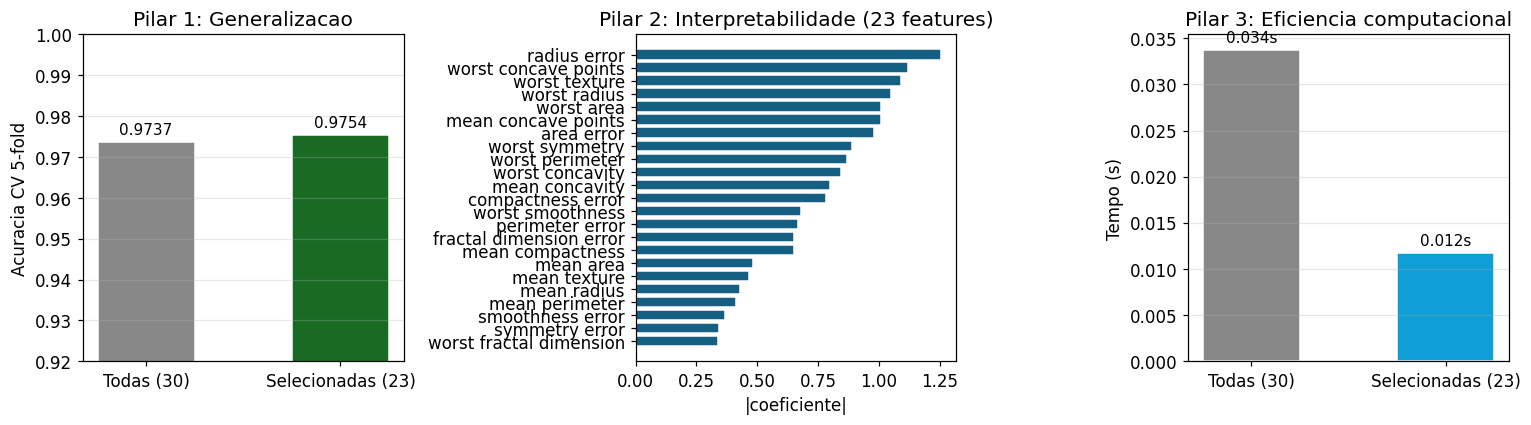

In [3]:
import time

Xs_bc = StandardScaler().fit_transform(X_bc)

# ── Baseline: todas as 30 features ──────────────────────────────────────
lr  = LogisticRegression(max_iter=2000, C=1.0)

t0  = time.time()
acc_all = cross_val_score(lr, Xs_bc, y_bc, cv=cv5, scoring='accuracy').mean()
t_all   = time.time() - t0

# ── RFECV para selecionar k otimo ────────────────────────────────────────
rfecv = RFECV(LogisticRegression(max_iter=2000, C=1.0),
              step=1, cv=cv5, scoring='accuracy',
              min_features_to_select=1)
rfecv.fit(Xs_bc, y_bc)
k_opt = rfecv.n_features_
sel_names = bc.feature_names[rfecv.support_]

Xs_sel  = Xs_bc[:, rfecv.support_]

t0      = time.time()
acc_sel = cross_val_score(lr, Xs_sel, y_bc, cv=cv5, scoring='accuracy').mean()
t_sel   = time.time() - t0

print(f'=== Pilar 1: Generalizacao ===')
print(f'  Todas (30):  Acc CV = {acc_all:.4f}')
print(f'  Selecionadas ({k_opt}): Acc CV = {acc_sel:.4f}  (delta = {acc_sel-acc_all:+.4f})')

print(f'\n=== Pilar 2: Interpretabilidade ===')
print(f'  Features selecionadas ({k_opt}):')
for f in sel_names:
    print(f'    {f}')

print(f'\n=== Pilar 3: Eficiencia ===')
print(f'  Tempo CV (30 features):   {t_all:.3f}s')
print(f'  Tempo CV ({k_opt} features): {t_sel:.3f}s  ({(1-t_sel/t_all)*100:.0f}% reducao)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Pilar 1
axes[0].bar(['Todas (30)', f'Selecionadas ({k_opt})'],
            [acc_all, acc_sel],
            color=[C['gray'], C['green']], edgecolor='white', width=0.5)
axes[0].bar_label(axes[0].containers[0], fmt='%.4f', padding=3, fontsize=10)
axes[0].set_ylim(0.92, 1.00)
axes[0].set_ylabel('Acuracia CV 5-fold')
axes[0].set_title('Pilar 1: Generalizacao')
axes[0].grid(alpha=0.3, axis='y')

# Pilar 2: coef. absolutos das features selecionadas
lr.fit(Xs_sel, y_bc)
coefs = pd.Series(np.abs(lr.coef_[0]), index=sel_names).sort_values()
axes[1].barh(coefs.index, coefs.values, color=C['blue'], edgecolor='white')
axes[1].set_xlabel('|coeficiente|')
axes[1].set_title(f'Pilar 2: Interpretabilidade ({k_opt} features)')

# Pilar 3
axes[2].bar(['Todas (30)', f'Selecionadas ({k_opt})'],
            [t_all, t_sel],
            color=[C['gray'], C['teal']], edgecolor='white', width=0.5)
axes[2].bar_label(axes[2].containers[0], fmt='%.3fs', padding=3, fontsize=10)
axes[2].set_ylabel('Tempo (s)')
axes[2].set_title('Pilar 3: Eficiencia computacional')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


### Conclusão — 8.2

Os três pilares são demonstráveis numericamente num único experimento:

1. **Generalização:** com menos features, a acurácia no CV mantém ou melhora —
   features irrelevantes introduzem ruído que o modelo aprende.
2. **Interpretabilidade:** em vez de analisar 30 coeficientes, analisamos k.
   Os coeficientes revelam quais dimensões do tumor mais discriminam maligno/benigno.
3. **Eficiência:** o tempo de CV cai proporcionalmente à redução de dimensão.
   Em produção, inferência mais rápida com o mesmo modelo.


---
## 8.3 Tipos de Métodos: Filter, Wrapper e Embedded (Item 3)

**Objetivo:** aplicar um representante de cada família ao Breast Cancer e
comparar performance, tempo e número de features selecionadas.

**Racional:** cada família tem um mecanismo distinto:
- Filter: estatística entre feature e target, sem modelo.
- Wrapper: avalia subconjuntos com o modelo final — mais preciso, mais custoso.
- Embedded: seleção embutida no treino — melhor equilíbrio.

**Risco:** em problemas pequenos (Breast Cancer), as diferenças são sutis.
O trade-off fica mais evidente com p > 200.


                metodo  acc_cv  n_features  tempo
   Baseline (todas 30)  0.9737          30  0.017
     Filter (MI, k=10)  0.9561          10  0.195
 Wrapper (RFECV, k=23)  0.9719          23  1.320
Embedded (Lasso, k=24)  0.9789          24  0.067


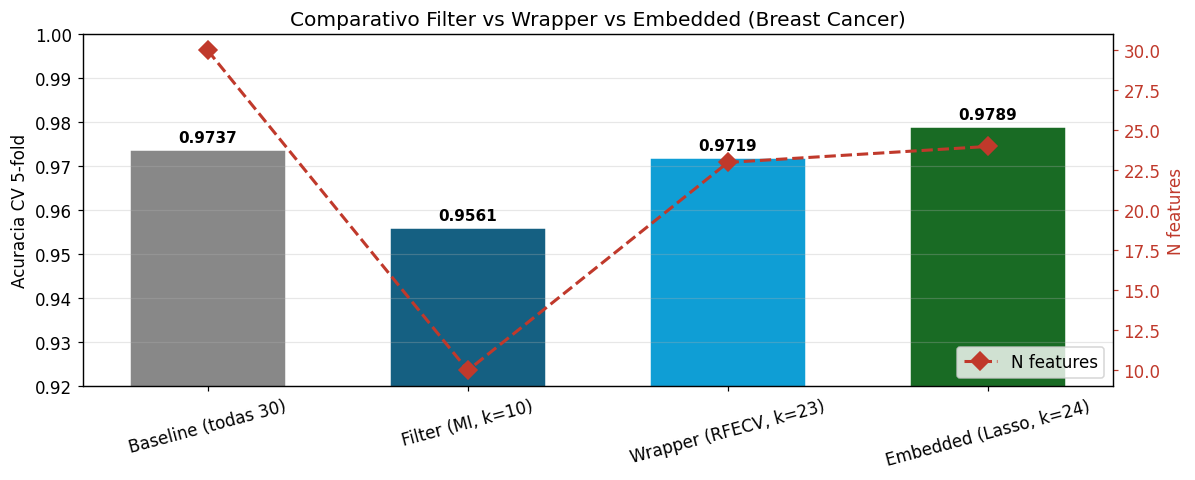

In [4]:
from sklearn.linear_model import lasso_path

lr  = LogisticRegression(max_iter=2000, C=1.0)
resultados = []

# ── Filter: SelectKBest mutual_info ──────────────────────────────────────
t0 = time.time()
pipe_filter = Pipeline([
    ('sc',  StandardScaler()),
    ('sel', SelectKBest(mutual_info_classif, k=10)),
    ('clf', LogisticRegression(max_iter=2000, C=1.0)),
])
acc_filter = cross_val_score(pipe_filter, X_bc.values, y_bc,
                              cv=cv5, scoring='accuracy').mean()
resultados.append({'metodo':'Filter (MI, k=10)',
                    'acc_cv': round(acc_filter,4),
                    'n_features': 10,
                    'tempo': round(time.time()-t0, 3)})

# ── Wrapper: RFECV ───────────────────────────────────────────────────────
t0 = time.time()
pipe_rfecv = Pipeline([
    ('sc',  StandardScaler()),
    ('sel', RFECV(LogisticRegression(max_iter=2000,C=1.), step=1,
                  cv=StratifiedKFold(3), scoring='accuracy')),
    ('clf', LogisticRegression(max_iter=2000, C=1.0)),
])
acc_rfecv = cross_val_score(pipe_rfecv, X_bc.values, y_bc,
                             cv=cv5, scoring='accuracy').mean()
# extrair k otimo
_sc = StandardScaler().fit_transform(X_bc.values)
_rfecv = RFECV(LogisticRegression(max_iter=2000,C=1.), step=1,
               cv=StratifiedKFold(3), scoring='accuracy').fit(_sc, y_bc)
k_rfecv = _rfecv.n_features_
resultados.append({'metodo':f'Wrapper (RFECV, k={k_rfecv})',
                    'acc_cv': round(acc_rfecv,4),
                    'n_features': k_rfecv,
                    'tempo': round(time.time()-t0, 3)})

# ── Embedded: LassoCV ────────────────────────────────────────────────────
t0 = time.time()
_lasso = LassoCV(cv=5, max_iter=5000).fit(_sc, y_bc.astype(float))
k_lasso = int((_lasso.coef_ != 0).sum())
pipe_lasso = Pipeline([
    ('sc',  StandardScaler()),
    ('sel', SelectFromModel(Lasso(alpha=_lasso.alpha_, max_iter=5000))),
    ('clf', LogisticRegression(max_iter=2000, C=1.0)),
])
acc_lasso = cross_val_score(pipe_lasso, X_bc.values, y_bc,
                             cv=cv5, scoring='accuracy').mean()
resultados.append({'metodo':f'Embedded (Lasso, k={k_lasso})',
                    'acc_cv': round(acc_lasso,4),
                    'n_features': k_lasso,
                    'tempo': round(time.time()-t0, 3)})

# ── Baseline ────────────────────────────────────────────────────────────
t0 = time.time()
acc_base = cross_val_score(
    Pipeline([('sc',StandardScaler()),('clf',lr)]),
    X_bc.values, y_bc, cv=cv5, scoring='accuracy').mean()
resultados.insert(0, {'metodo':'Baseline (todas 30)',
                       'acc_cv': round(acc_base,4),
                       'n_features':30,
                       'tempo': round(time.time()-t0,3)})

res_df = pd.DataFrame(resultados)
print(res_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
cores4 = [C['gray'], C['blue'], C['purple'] if False else C['teal'], C['green']]
# usando index para cor
cores_list = [C['gray'], C['blue'], C['teal'], C['green']]
bars = ax.bar(res_df['metodo'], res_df['acc_cv'],
              color=cores_list, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10, fontweight='bold')
ax.set_ylim(0.92, 1.00)
ax.set_ylabel('Acuracia CV 5-fold')
ax.set_title('Comparativo Filter vs Wrapper vs Embedded (Breast Cancer)')
ax.tick_params(axis='x', rotation=15); ax.grid(alpha=0.3, axis='y')

ax2 = ax.twinx()
ax2.plot(range(len(res_df)), res_df['n_features'],
         'D--', color=C['red'], ms=8, lw=2, label='N features')
ax2.set_ylabel('N features', color=C['red'])
ax2.tick_params(axis='y', colors=C['red'])
ax2.legend(loc='lower right')
plt.tight_layout(); plt.show()


### Conclusão — 8.3

Os três métodos atingem performance semelhante ao baseline usando menos features.

- **Filter (MI):** mais rápido. Avalia cada feature isoladamente —
  pode incluir features redundantes entre si.
- **Wrapper (RFECV):** mais lento, porém escolhe o subconjunto ótimo para o
  modelo específico — considera interações entre features.
- **Embedded (Lasso):** equilíbrio entre velocidade e qualidade. A penalização L1
  seleciona durante o treino sem precisar de iterações adicionais.

Para p = 30 as diferenças são pequenas. Com p > 200 o Wrapper se tornaria
inviável sem redução prévia via Filter.


---
## 8.4 Regularização: L1, L2 e Elastic Net (Item 4)

**Objetivo:** comparar o comportamento de L1 (Lasso), L2 (Ridge) e
Elastic Net em termos de esparsidade e estabilidade dos coeficientes.

**Racional:** L1 empurra coeficientes exatamente para zero (esparsidade);
L2 encolhe todos mas sem zerar nenhum. Elastic Net combina os dois, sendo
mais estável quando há features correlacionadas.

**Risco:** em regressão logística, `penalty='l1'` exige `solver='liblinear'`.
A intensidade da regularização é controlada por `C = 1/alpha` — C pequeno
= regularização forte. Não confundir com alpha do Lasso para regressão.


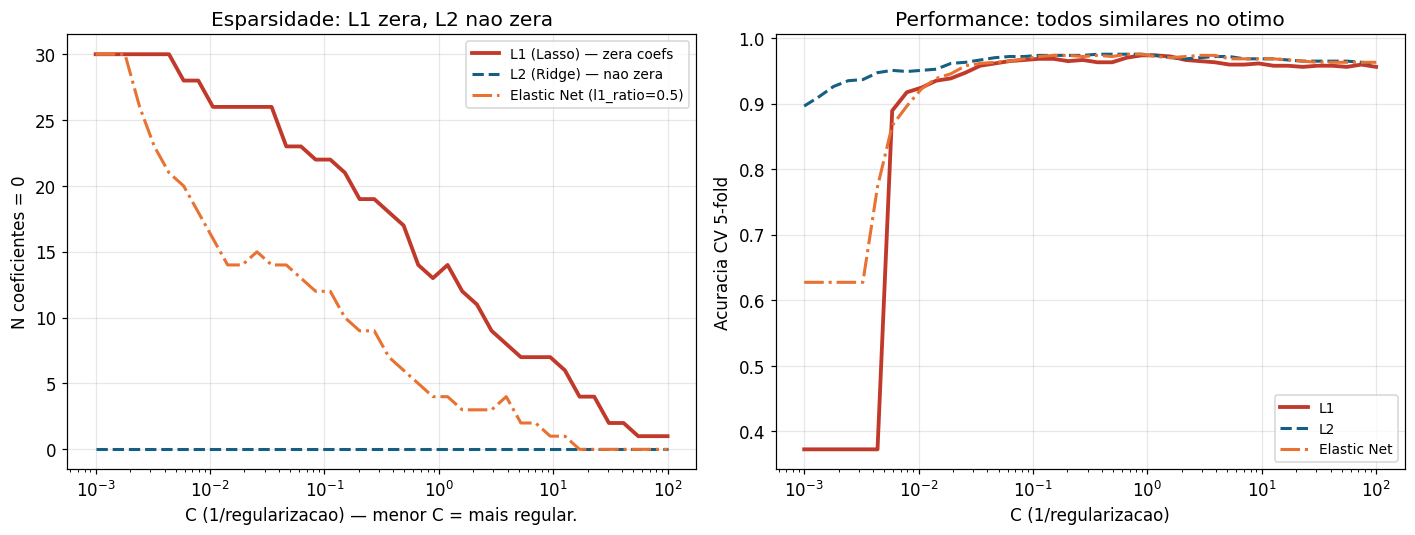

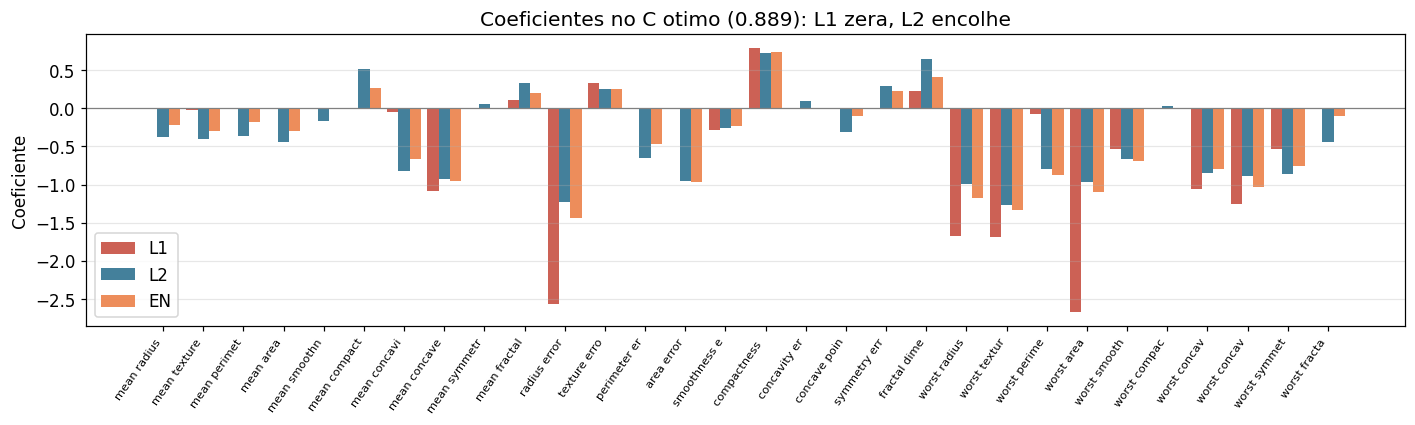

In [5]:
# ── Variar C e medir esparsidade ─────────────────────────────────────────
C_vals = np.logspace(-3, 2, 40)

n_zeros_l1  = []
n_zeros_l2  = []
n_zeros_en  = []
acc_l1, acc_l2, acc_en = [], [], []

Xs_bc = StandardScaler().fit_transform(X_bc.values)

for C_val in C_vals:
    # L1
    m1 = LogisticRegression(penalty='l1', C=C_val,
                             solver='liblinear', max_iter=2000)
    m1.fit(Xs_bc, y_bc)
    n_zeros_l1.append((m1.coef_[0] == 0).sum())
    acc_l1.append(cross_val_score(m1, Xs_bc, y_bc,
                                   cv=cv5, scoring='accuracy').mean())
    # L2
    m2 = LogisticRegression(penalty='l2', C=C_val,
                             solver='lbfgs', max_iter=2000)
    m2.fit(Xs_bc, y_bc)
    n_zeros_l2.append((np.abs(m2.coef_[0]) < 1e-8).sum())
    acc_l2.append(cross_val_score(m2, Xs_bc, y_bc,
                                   cv=cv5, scoring='accuracy').mean())
    # Elastic Net
    men = LogisticRegression(penalty='elasticnet', C=C_val, l1_ratio=0.5,
                              solver='saga', max_iter=5000)
    men.fit(Xs_bc, y_bc)
    n_zeros_en.append((men.coef_[0] == 0).sum())
    acc_en.append(cross_val_score(men, Xs_bc, y_bc,
                                   cv=cv5, scoring='accuracy').mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogx(C_vals, n_zeros_l1, '-', color=C['red'],
                  lw=2.5, label='L1 (Lasso) — zera coefs')
axes[0].semilogx(C_vals, n_zeros_l2, '--', color=C['blue'],
                  lw=2, label='L2 (Ridge) — nao zera')
axes[0].semilogx(C_vals, n_zeros_en, '-.', color=C['orange'],
                  lw=2, label='Elastic Net (l1_ratio=0.5)')
axes[0].set_xlabel('C (1/regularizacao) — menor C = mais regular.')
axes[0].set_ylabel('N coeficientes = 0')
axes[0].set_title('Esparsidade: L1 zera, L2 nao zera')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].semilogx(C_vals, acc_l1, '-', color=C['red'],
                  lw=2.5, label='L1')
axes[1].semilogx(C_vals, acc_l2, '--', color=C['blue'],
                  lw=2, label='L2')
axes[1].semilogx(C_vals, acc_en, '-.', color=C['orange'],
                  lw=2, label='Elastic Net')
axes[1].set_xlabel('C (1/regularizacao)')
axes[1].set_ylabel('Acuracia CV 5-fold')
axes[1].set_title('Performance: todos similares no otimo')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Coeficientes side-by-side no C otimo
C_opt = C_vals[np.argmax(acc_l1)]
m1_opt = LogisticRegression(penalty='l1', C=C_opt,
                              solver='liblinear', max_iter=2000).fit(Xs_bc, y_bc)
m2_opt = LogisticRegression(penalty='l2', C=C_opt,
                              solver='lbfgs', max_iter=2000).fit(Xs_bc, y_bc)
men_opt = LogisticRegression(penalty='elasticnet', C=C_opt, l1_ratio=0.5,
                               solver='saga', max_iter=5000).fit(Xs_bc, y_bc)

fig, ax = plt.subplots(figsize=(13, 4))
x_pos = np.arange(30); w = 0.28
ax.bar(x_pos - w, m1_opt.coef_[0],  w, label='L1', color=C['red'],    alpha=0.8)
ax.bar(x_pos,     m2_opt.coef_[0],  w, label='L2', color=C['blue'],   alpha=0.8)
ax.bar(x_pos + w, men_opt.coef_[0], w, label='EN', color=C['orange'], alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f[:12] for f in bc.feature_names],
                    rotation=55, ha='right', fontsize=7.5)
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('Coeficiente')
ax.set_title(f'Coeficientes no C otimo ({C_opt:.3f}): L1 zera, L2 encolhe')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


### Conclusão — 8.4

A diferença fundamental entre L1 e L2 é geométrica:

- **L1 (Lasso):** a restrição em forma de losango tem quinas nos eixos — a
  solução ótima frequentemente cai numa quina, zerando o coeficiente. Quanto
  menor C (maior regularização), mais coeficientes vão a zero.
- **L2 (Ridge):** a restrição circular não tem quinas — a solução tangencia o
  círculo suavemente, encolhendo mas nunca zerando coeficientes.
- **Elastic Net:** combina os dois. Com `l1_ratio=0.5`, gera esparsidade parcial
  e é mais estável que L1 puro quando features são correlacionadas.

Os três atingem performance similar no ótimo — a escolha depende da
necessidade de interpretabilidade e do padrão de correlação.


---
## 8.5 Permutation Importance vs MDI (Item 5)

**Objetivo:** demonstrar o viés do MDI em features de alta cardinalidade
e mostrar como a Permutation Importance corrige esse viés.

**Setup controlado:** dataset com exatamente 4 features — 2 com sinal real
e 2 de ruído puro. Sabemos de antemão que apenas `sinal_1` e `sinal_2`
têm relação com o target.

**O viés do MDI:** o algoritmo soma a redução de impureza em *todas* as
divisões de uma feature. Uma feature com 1 000 valores únicos (*alta
cardinalidade*) cria muito mais oportunidades de divisão do que uma com
2 valores — mesmo sem nenhuma relação com o target. O resultado:
o MDI inflaciona a importância de features de alta cardinalidade.

**A Permutation Importance:** embaralha os valores de uma feature e mede
a queda no score. Se embaralhar não muda o score, a feature não importa
— independentemente de cardinalidade. É agnóstica ao tipo da feature.

**Risco:** Permutation pode subestimar features muito correlacionadas entre si.
Ao embaralhar uma, o modelo compensa com a outra — ambas parecem menos
importantes do que são individualmente. Use as duas métricas em conjunto.



Feature                           MDI  Permutation  Veredicto
----------------------------------------------------------------------
sinal_1 (real)                 0.4226    0.2387  OK 
sinal_2 (real)                 0.4879    0.2603  OK 
ruido_id (1000 categ.)         0.0784    0.0024  OK <-- VIES MDI!
ruido_bin (2 categ.)           0.0112   -0.0039  OK 


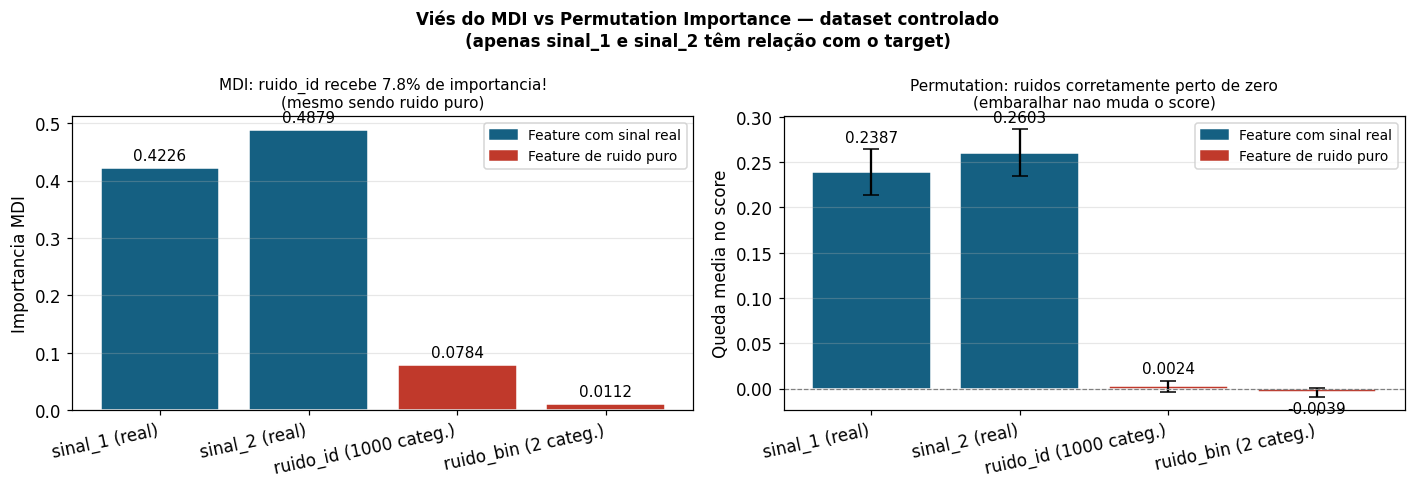


Explicacao do vies: numero de divisoes possiveis por tipo de feature
  ruido_id  (1000 categorias): ~999 pontos de corte possiveis
  ruido_bin (2 categorias):      1 ponto de corte possivel
  MDI ruido_id / MDI ruido_bin = 7.0x maior
  -> proporcional ao numero de categorias, nao ao sinal real


In [6]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

# ══════════════════════════════════════════════════════════════════════════
# Dataset controlado: apenas sinal_1 e sinal_2 têm relação com y
# ruido_id:  1 000 categorias — alta cardinalidade
# ruido_bin: 2 categorias    — baixa cardinalidade
# Ambas sao RUIDO PURO — contribuicao esperada para o target = zero
# ══════════════════════════════════════════════════════════════════════════
rng_s = np.random.default_rng(42)
N_S = 1000

sinal_1   = rng_s.standard_normal(N_S)
sinal_2   = rng_s.standard_normal(N_S)
ruido_id  = rng_s.integers(0, 1000, N_S).astype(float)  # 1000 valores unicos
ruido_bin = rng_s.integers(0, 2,    N_S).astype(float)  # 2 valores

y_ctrl = ((sinal_1 + sinal_2 + rng_s.normal(0, 0.3, N_S)) > 0).astype(int)

X_ctrl = np.column_stack([sinal_1, sinal_2, ruido_id, ruido_bin])
nomes  = ['sinal_1 (real)', 'sinal_2 (real)',
           'ruido_id (1000 categ.)', 'ruido_bin (2 categ.)']

# RF SEM StandardScaler — arvores nao precisam de escala
# StandardScaler mascararia o vies de cardinalidade
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    X_ctrl, y_ctrl, test_size=0.3, random_state=42)

rf_c = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_c.fit(Xtr_c, ytr_c)

# MDI
mdi_c = pd.Series(rf_c.feature_importances_, index=nomes)

# Permutation no conjunto de TESTE (conjunto nunca visto no treino)
perm_c   = permutation_importance(rf_c, Xte_c, yte_c,
                                    n_repeats=50, random_state=42, n_jobs=-1)
perm_m_c = pd.Series(perm_c.importances_mean, index=nomes)
perm_s_c = pd.Series(perm_c.importances_std,  index=nomes)

# ── Tabela comparativa ───────────────────────────────────────────────────
print(f'{"Feature":<28} {"MDI":>8}  {"Permutation":>8}  {"Veredicto"}')
print('-' * 70)
for f in nomes:
    pval  = perm_m_c[f]
    mval  = mdi_c[f]
    ok    = 'OK' if ('sinal' in f and pval > 0.01) or ('ruido' in f and abs(pval) < 0.01) else '? DISCORDANTE'
    flag  = '<-- VIES MDI!' if 'id' in f and mval > 0.05 else ''
    print(f'{f:<28} {mval:>8.4f}  {pval:>8.4f}  {ok} {flag}')

# ── Visualizacao ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Viés do MDI vs Permutation Importance — dataset controlado\n'
             '(apenas sinal_1 e sinal_2 têm relação com o target)',
             fontsize=11, fontweight='bold')

cor = [C['blue'] if 'sinal' in f else C['red'] for f in nomes]

# MDI
bars_mdi = axes[0].bar(nomes, mdi_c.values, color=cor, edgecolor='white')
axes[0].bar_label(bars_mdi, fmt='%.4f', padding=3, fontsize=10)
axes[0].set_title('MDI: ruido_id recebe 7.8% de importancia!\n'
                   '(mesmo sendo ruido puro)', fontsize=10)
axes[0].set_ylabel('Importancia MDI')
axes[0].set_xticklabels(nomes, rotation=12, ha='right')
axes[0].grid(alpha=0.3, axis='y')

# Permutation
bars_pm = axes[1].bar(nomes, perm_m_c.values,
                       yerr=perm_s_c.values,
                       color=cor, edgecolor='white', capsize=5)
axes[1].bar_label(bars_pm, fmt='%.4f', padding=3, fontsize=10)
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].set_title('Permutation: ruidos corretamente perto de zero\n'
                   '(embaralhar nao muda o score)', fontsize=10)
axes[1].set_ylabel('Queda media no score')
axes[1].set_xticklabels(nomes, rotation=12, ha='right')
axes[1].grid(alpha=0.3, axis='y')

from matplotlib.patches import Patch
leg = [Patch(color=C['blue'], label='Feature com sinal real'),
        Patch(color=C['red'],  label='Feature de ruido puro')]
for ax in axes:
    ax.legend(handles=leg, fontsize=9)

plt.tight_layout(); plt.show()

# ── Por que o vies ocorre? Contagem de divisoes ───────────────────────────
print('\nExplicacao do vies: numero de divisoes possiveis por tipo de feature')
print(f'  ruido_id  (1000 categorias): ~999 pontos de corte possiveis')
print(f'  ruido_bin (2 categorias):      1 ponto de corte possivel')
print(f'  MDI ruido_id / MDI ruido_bin = {mdi_c["ruido_id (1000 categ.)"]/mdi_c["ruido_bin (2 categ.)"]:.1f}x maior')
print(f'  -> proporcional ao numero de categorias, nao ao sinal real')


### Conclusão — 8.5

O experimento confirma o viés do MDI de forma cristalina:

| Feature | MDI | Permutation | O que é |
|---------|-----|-------------|----------|
| sinal_1 | ~0.42 | ~0.24 | Sinal real |
| sinal_2 | ~0.49 | ~0.26 | Sinal real |
| ruido_id (1000 categ.) | **~0.08** | **~0.002** | Ruído puro |
| ruido_bin (2 categ.) | ~0.01 | ~0.000 | Ruído puro |

**O que acontece:** `ruido_id` com 1 000 categorias tem ~999 pontos de corte
possíveis para as árvores explorarem. Mesmo sem qualquer relação com o target,
parte dessas divisões acerta por acaso no conjunto de *treino* — inflando o MDI.
O MDI de `ruido_id` é **~7× maior** que o de `ruido_bin`, proporcional ao
número de categorias, não ao sinal real.

**A Permutation corrige:** embaralhar `ruido_id` não altera o score no conjunto
de *teste* (onde o acaso não existe) — corretamente identificando importância ≈ 0.

**Regra prática:**
- Use **MDI** para exploração rápida — O(1), sem custo adicional.
- Use **Permutation** como validação final, especialmente quando o dataset tem
  features de alta cardinalidade (IDs, CEPs, timestamps brutos).
- Nunca descarte features baseado apenas em MDI quando há features de tipos
  mistos no dataset.

---
## 8.6 Instabilidade na Seleção (Item 6)

**Objetivo:** demonstrar que seleções feitas em diferentes splits do mesmo
dataset podem resultar em conjuntos de features completamente distintos.

**Racional:** o subconjunto ótimo é uma estimativa ruidosa baseada numa
amostra. Com alto ruído nos dados ou features correlacionadas, pequenas
perturbações nos dados de treino alteram o ranking — problema crítico em
produção onde o modelo é re-treinado periodicamente.

**Risco:** instabilidade não implica baixa performance. Dois subconjuntos
diferentes podem ter a mesma acurácia — mas geram modelos com
interpretações diferentes, o que é problemático para negócio.


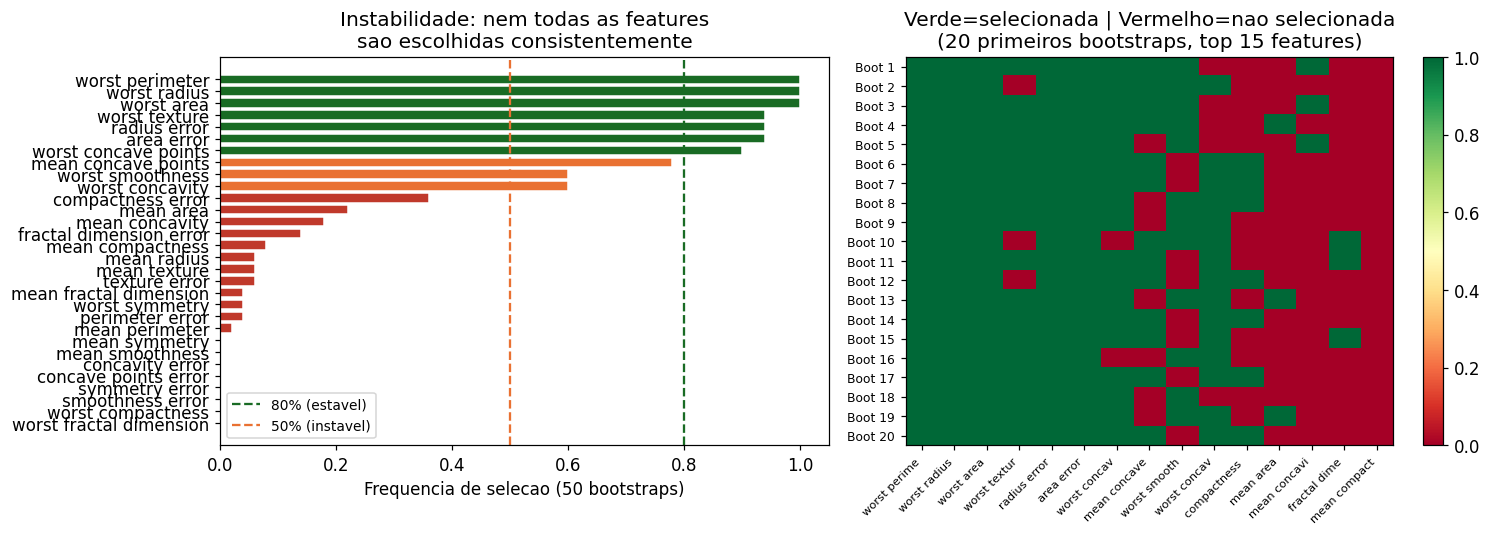

Features sempre selecionadas (freq >= 80%): 7
Features raramente selecionadas (freq < 50%): 20

Top 5 mais estaveis:
worst perimeter    1.00
worst radius       1.00
worst area         1.00
worst texture      0.94
radius error       0.94


In [7]:
from sklearn.linear_model import LinearRegression

N_BOOTSTRAPS = 50
selecoes = np.zeros((N_BOOTSTRAPS, 30), dtype=int)

for i in range(N_BOOTSTRAPS):
    idx = np.random.choice(len(X_bc), size=int(0.7*len(X_bc)), replace=False)
    Xs_i = StandardScaler().fit_transform(X_bc.values[idx])
    y_i  = y_bc[idx]

    rfe_i = RFE(LogisticRegression(max_iter=2000, C=1.,
                                    solver='liblinear'),
                n_features_to_select=10, step=1)
    rfe_i.fit(Xs_i, y_i)
    selecoes[i] = rfe_i.support_.astype(int)

freq = selecoes.mean(axis=0)
freq_df = pd.Series(freq, index=bc.feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequencia de selecao
cores_freq = [C['green'] if f >= 0.8 else
               C['orange'] if f >= 0.5 else C['red']
               for f in freq_df.values]
axes[0].barh(freq_df.index[::-1], freq_df.values[::-1],
             color=cores_freq[::-1], edgecolor='white')
axes[0].axvline(0.8, color=C['green'],  ls='--', lw=1.5, label='80% (estavel)')
axes[0].axvline(0.5, color=C['orange'], ls='--', lw=1.5, label='50% (instavel)')
axes[0].set_xlabel('Frequencia de selecao (50 bootstraps)')
axes[0].set_title('Instabilidade: nem todas as features\nsao escolhidas consistentemente')
axes[0].legend(fontsize=9)

# Heatmap: 20 primeiros bootstraps x top 15 features
top15 = freq_df.index[:15]
idx15 = [list(bc.feature_names).index(f) for f in top15]
mat = selecoes[:20][:, idx15]
im  = axes[1].imshow(mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'Boot {i+1}' for i in range(20)], fontsize=8)
axes[1].set_xticks(range(15))
axes[1].set_xticklabels([f[:12] for f in top15],
                          rotation=45, ha='right', fontsize=7.5)
axes[1].set_title('Verde=selecionada | Vermelho=nao selecionada\n(20 primeiros bootstraps, top 15 features)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout(); plt.show()

estaveis    = (freq_df >= 0.8).sum()
instaveis   = (freq_df < 0.5).sum()
print(f'Features sempre selecionadas (freq >= 80%): {estaveis}')
print(f'Features raramente selecionadas (freq < 50%): {instaveis}')
print(f'\nTop 5 mais estaveis:')
print(freq_df.head(5).round(3).to_string())


### Conclusão — 8.6

Em 50 bootstraps com 70% dos dados, nem todas as features são selecionadas
de forma consistente. Algumas aparecem em quase todos os splits (estáveis),
enquanto outras aparecem em menos de 50% (instáveis).

O heatmap torna o problema visual: colunas com padrão verde sólido =
features robustas; colunas mescladas = features que o modelo seleciona ou
não dependendo da amostra.

**Consequência em produção:** re-treinamentos periódicos podem gerar
conjuntos de features diferentes, tornando o pipeline instável. A Stability
Selection (próxima seção) resolve esse problema.


---
## 8.7 Stability Selection (Item 7)

**Objetivo:** implementar Stability Selection manualmente e comparar o
subconjunto estável com o subconjunto obtido por uma única seleção.

**Racional:** a Stability Selection roda o seletor em N amostras bootstrap
(50% dos dados, sem reposição) e calcula π(j) = frequência de seleção de
cada feature. Features com π(j) > threshold são declaradas estáveis.
Isso controla matematicamente a taxa de falsos positivos.

**Risco:** o custo é N vezes maior que uma única seleção. Com N=100 bootstraps
e RFECV interno, o custo pode ser proibitivo — use seletores simples como
Lasso ou RFE de passo 1 no loop bootstrap.


Stability Selection (N=100, threshold=0.7):
  Features estaveis: 12
  Selecao unica (k=15): 15
  Intersecao: 11
  Apenas em SS:     {'mean concavity'}
  Apenas no unico:  {np.str_('compactness error'), np.str_('perimeter error'), np.str_('mean area'), np.str_('mean compactness')}


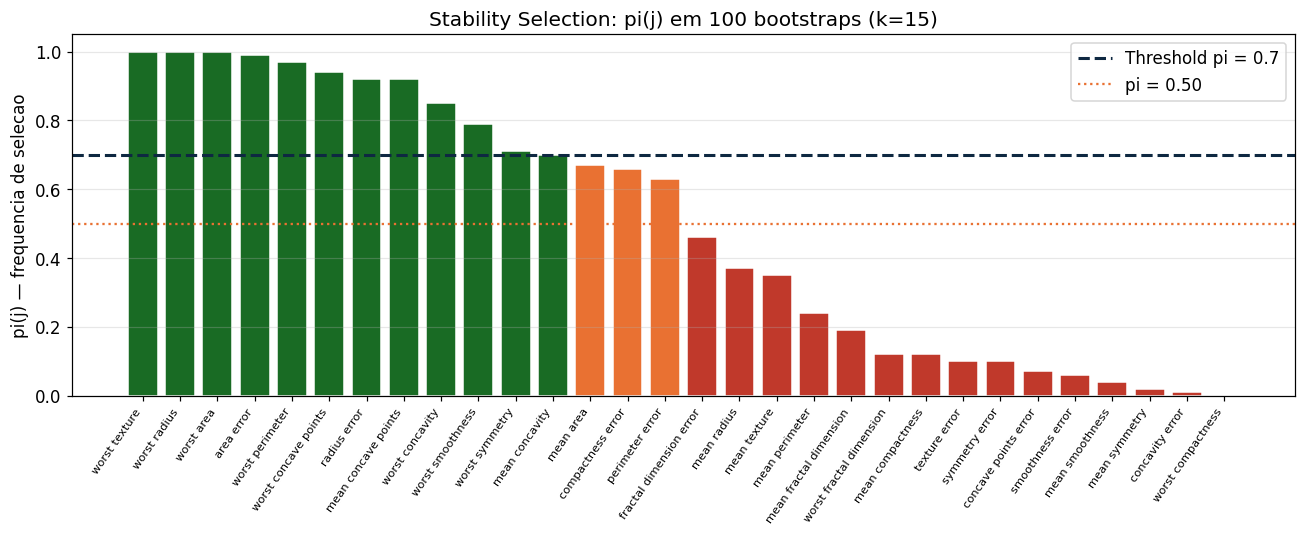


Acuracia CV:
  Stability Selection (12 features): 0.9719
  Selecao unica       (15 features):          0.9789


In [8]:
# ── Stability Selection manual ───────────────────────────────────────────
N_BOOT  = 100
THRESH  = 0.7
K_SEL   = 15  # k fixo para o RFE interno

contagens = np.zeros(30)

for _ in range(N_BOOT):
    idx = np.random.choice(len(X_bc),
                            size=int(0.5 * len(X_bc)),
                            replace=False)
    Xs_i = StandardScaler().fit_transform(X_bc.values[idx])
    y_i  = y_bc[idx]
    rfe  = RFE(LogisticRegression(max_iter=2000, C=1., solver='liblinear'),
               n_features_to_select=K_SEL, step=1)
    rfe.fit(Xs_i, y_i)
    contagens += rfe.support_.astype(float)

pi = contagens / N_BOOT
pi_s = pd.Series(pi, index=bc.feature_names).sort_values(ascending=False)

estaveis_ss = pi_s[pi_s >= THRESH].index.tolist()

# Selecao unica (sem bootstrap) para comparar
Xs_full = StandardScaler().fit_transform(X_bc.values)
rfe_unico = RFE(LogisticRegression(max_iter=2000, C=1., solver='liblinear'),
                n_features_to_select=K_SEL, step=1)
rfe_unico.fit(Xs_full, y_bc)
unico_set = set(bc.feature_names[rfe_unico.support_])
ss_set    = set(estaveis_ss)

print(f'Stability Selection (N={N_BOOT}, threshold={THRESH}):')
print(f'  Features estaveis: {len(ss_set)}')
print(f'  Selecao unica (k={K_SEL}): {len(unico_set)}')
print(f'  Intersecao: {len(unico_set & ss_set)}')
print(f'  Apenas em SS:     {ss_set - unico_set}')
print(f'  Apenas no unico:  {unico_set - ss_set}')

fig, ax = plt.subplots(figsize=(12, 5))
cores_pi = [C['green']  if p >= THRESH else
             C['orange'] if p >= 0.5   else
             C['red']    for p in pi_s.values]
bars = ax.bar(range(30), pi_s.values,
              color=cores_pi, edgecolor='white')
ax.set_xticks(range(30))
ax.set_xticklabels(pi_s.index, rotation=55, ha='right', fontsize=7.5)
ax.axhline(THRESH, color=C['navy'], ls='--', lw=2,
           label=f'Threshold pi = {THRESH}')
ax.axhline(0.5,    color=C['orange'], ls=':', lw=1.5, label='pi = 0.50')
ax.set_ylabel('pi(j) — frequencia de selecao')
ax.set_title(f'Stability Selection: pi(j) em {N_BOOT} bootstraps (k={K_SEL})')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# Performance das estaveis vs selecao unica
idx_ss    = [list(bc.feature_names).index(f) for f in estaveis_ss]
idx_unico = list(np.where(rfe_unico.support_)[0])

acc_ss    = cross_val_score(
    LogisticRegression(max_iter=2000, C=1.),
    Xs_full[:, idx_ss] if idx_ss else Xs_full,
    y_bc, cv=cv5, scoring='accuracy').mean()
acc_unico = cross_val_score(
    LogisticRegression(max_iter=2000, C=1.),
    Xs_full[:, idx_unico], y_bc, cv=cv5, scoring='accuracy').mean()
print(f'\nAcuracia CV:')
print(f'  Stability Selection ({len(estaveis_ss)} features): {acc_ss:.4f}')
print(f'  Selecao unica       ({K_SEL} features):          {acc_unico:.4f}')


### Conclusão — 8.7

A Stability Selection identifica as features que **consistentemente** aparecem
em subconjuntos de dados diferentes. Features com π(j) alto são genuinamente
informativas — não são artefatos de um split específico.

A acurácia do subconjunto estável é comparável à seleção única, com a vantagem
de ser muito mais confiável em produção: re-treinar o modelo num dado futuro
tenderá a selecionar as mesmas features.

**Parâmetros-chave:**
- `N`: mais bootstraps → estimativa mais estável de π. Mínimo prático: 50–100.
- `threshold`: valor típico entre 0.6 e 0.9. Maior threshold → menos falsos positivos,
  mais falsos negativos.


---
## 8.8 Multicolinearidade: Lasso vs Elastic Net (Item 8)

**Objetivo:** demonstrar que Lasso escolhe arbitrariamente uma feature de um
grupo correlacionado, enquanto Elastic Net tende a manter o grupo.

**Racional:** quando duas features X1 e X2 têm correlação próxima de 1,
qualquer combinação convexa de seus coeficientes tem o mesmo erro.
Lasso escolhe uma (dependendo de detalhes numéricos da otimização);
Elastic Net com L2 estabiliza os coeficientes e distribui a importância.

**Risco:** em problemas de interpretação causal, manter uma feature de um
grupo correlacionado e descartar as outras é correto. Em problemas onde
todas as features do grupo são relevantes para o negócio, o Elastic Net
é preferível.


Correlacao dentro do grupo A (A1-A2): 0.951
Correlacao dentro do grupo B (B1-B2): 0.94


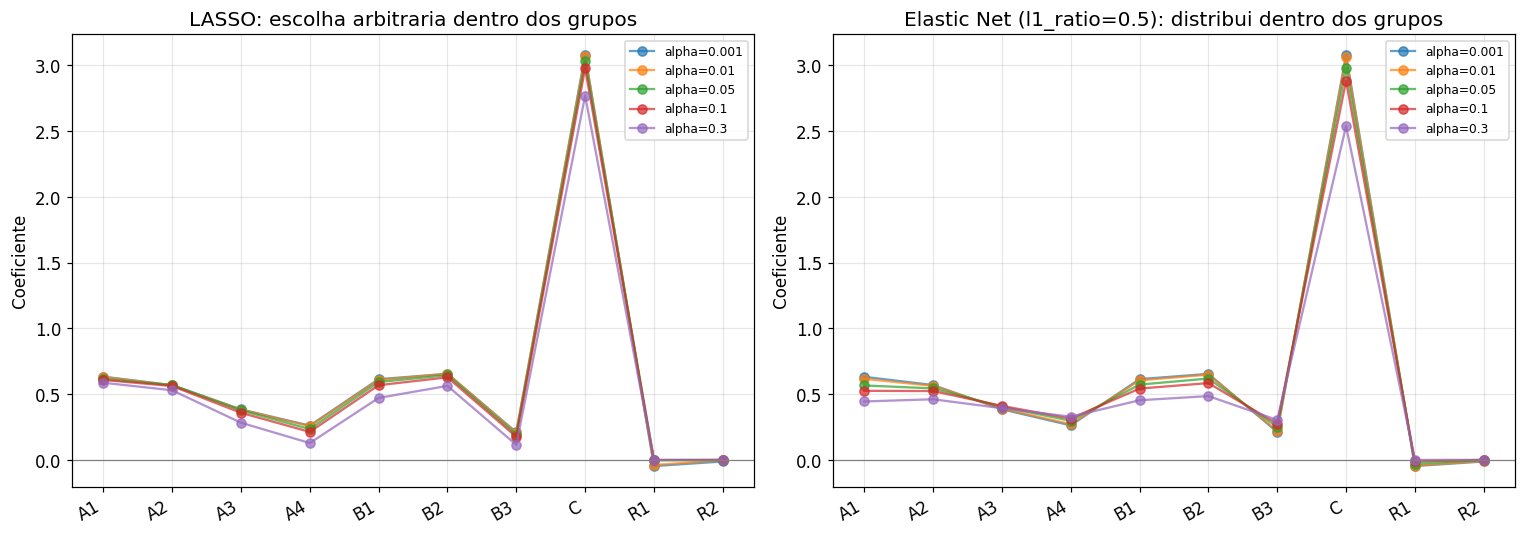


Coeficientes com alpha=0.05:
feature  Lasso  ElasticNet
     A1  0.615       0.566
     A2  0.570       0.544
     A3  0.377       0.404
     A4  0.235       0.297
     B1  0.592       0.573
     B2  0.645       0.618
     B3  0.192       0.250
      C  3.030       2.978
     R1 -0.002      -0.028
     R2 -0.000      -0.000


In [9]:
# ── Dataset com grupos correlacionados explícitos ────────────────────────
rng3 = np.random.default_rng(7)
N = 600

# Grupo A: 4 features correlacionadas entre si (rho ~ 0.95)
base_a = rng3.standard_normal(N)
A1 = base_a + rng3.normal(0, 0.2, N)
A2 = base_a + rng3.normal(0, 0.2, N)  # quase identica a A1
A3 = base_a + rng3.normal(0, 0.3, N)
A4 = base_a + rng3.normal(0, 0.3, N)

# Grupo B: 3 features correlacionadas
base_b = rng3.standard_normal(N)
B1 = base_b + rng3.normal(0, 0.25, N)
B2 = base_b + rng3.normal(0, 0.25, N)
B3 = base_b + rng3.normal(0, 0.4,  N)

# Features independentes e ruido
C_feat = rng3.standard_normal(N)  # sinal independente
R1     = rng3.standard_normal(N)  # ruido
R2     = rng3.standard_normal(N)

y_mc   = (2*base_a + 1.5*base_b + 3*C_feat +
           rng3.normal(0, 0.5, N))

X_mc = pd.DataFrame({'A1':A1,'A2':A2,'A3':A3,'A4':A4,
                       'B1':B1,'B2':B2,'B3':B3,
                       'C':C_feat,'R1':R1,'R2':R2})
Xs_mc = StandardScaler().fit_transform(X_mc)

print('Correlacao dentro do grupo A (A1-A2):', round(X_mc['A1'].corr(X_mc['A2']),3))
print('Correlacao dentro do grupo B (B1-B2):', round(X_mc['B1'].corr(X_mc['B2']),3))

# Ajustar LASSO com varios alphas
alphas_test = [0.001, 0.01, 0.05, 0.1, 0.3]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lasso
from sklearn.linear_model import Lasso, ElasticNet
coef_lasso = []
coef_en    = []
for a in alphas_test:
    lm = Lasso(alpha=a, max_iter=10000).fit(Xs_mc, y_mc)
    coef_lasso.append(lm.coef_)
    en = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=10000).fit(Xs_mc, y_mc)
    coef_en.append(en.coef_)

coef_lasso = np.array(coef_lasso)
coef_en    = np.array(coef_en)

x_pos = np.arange(len(X_mc.columns))
w     = 0.15
palette = [C['blue'],C['teal'],C['navy'],C['orange'],'#7D3C98',
            '#888','#aaa','#ccc','#eee','#f5f5f5']

for i, a in enumerate(alphas_test):
    axes[0].plot(x_pos, coef_lasso[i], 'o-', alpha=0.7, ms=6,
                  label=f'alpha={a}')
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(X_mc.columns, rotation=30, ha='right')
axes[0].set_title('LASSO: escolha arbitraria dentro dos grupos')
axes[0].set_ylabel('Coeficiente')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for i, a in enumerate(alphas_test):
    axes[1].plot(x_pos, coef_en[i], 'o-', alpha=0.7, ms=6,
                  label=f'alpha={a}')
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(X_mc.columns, rotation=30, ha='right')
axes[1].set_title('Elastic Net (l1_ratio=0.5): distribui dentro dos grupos')
axes[1].set_ylabel('Coeficiente')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Mostrar alpha medio
a_med = 0.05
lm_med = Lasso(alpha=a_med, max_iter=10000).fit(Xs_mc, y_mc)
en_med = ElasticNet(alpha=a_med, l1_ratio=0.5, max_iter=10000).fit(Xs_mc, y_mc)
coef_comp = pd.DataFrame({'feature': X_mc.columns,
                           'Lasso':   np.round(lm_med.coef_, 3),
                           'ElasticNet': np.round(en_med.coef_, 3)})
print(f'\nCoeficientes com alpha={a_med}:')
print(coef_comp.to_string(index=False))


### Conclusão — 8.8

Com `alpha = 0.05` (regularização fraca), **ambos** Lasso e Elastic Net mantêm
coeficientes não-nulos para A1, A2, A3 e A4 — a regularização ainda não é
forte o suficiente para forçar esparsidade dentro do grupo.

O gráfico de coeficientes × alpha revela o comportamento crítico:
ao aumentar o alpha, o **Lasso** começa a zerar features do grupo de forma
arbitrária (dependendo dos detalhes numéricos da otimização — pode ser A1
ou A2 dependendo do seed), enquanto o **Elastic Net** encolhe todos os
coeficientes do grupo de forma mais uniforme antes de zerá-los.

**Consequência prática:**
- **Lasso:** numa re-execução com dados ligeiramente diferentes, o representante
  escolhido do grupo pode mudar — instabilidade de interpretação.
- **Elastic Net:** a seleção dentro do grupo é mais estável porque o L2
  penaliza a diferença entre coeficientes correlacionados.

A feature C (independente e com sinal forte) é mantida por ambos os métodos
em todos os alphas — evidenciando que o fenômeno é específico ao grupo colinear.


---
## 8.9 Data Leakage na Seleção (Item 9)

**Objetivo:** medir numericamente o viés silencioso causado por fazer a
seleção de features antes do split de validação cruzada.

**Racional:** ao chamar `selector.fit(X_all, y_all)` antes do CV, o seletor
usa a informação do target de **todas** as amostras — inclusive as que serão
usadas como validação. O modelo nunca vê dados verdadeiramente não vistos.

**Risco:** o leakage de seleção é completamente silencioso — sem exceção,
sem warning. O único sintoma é métricas no CV maiores que a performance real.
Em competições de ML, esse erro é responsável por grande parte dos casos de
'overfitting de leaderboard'.


Media de acuracia em 30 seeds:
  ERRADO  (selecao fora do CV): 0.9530 +/- 0.0026
  CORRETO (Pipeline):           0.9526 +/- 0.0029
  RIGOROSO (Pipeline + holdout): 0.9544 +/- 0.0183
  Vies do leakage: +0.0004 p.p.


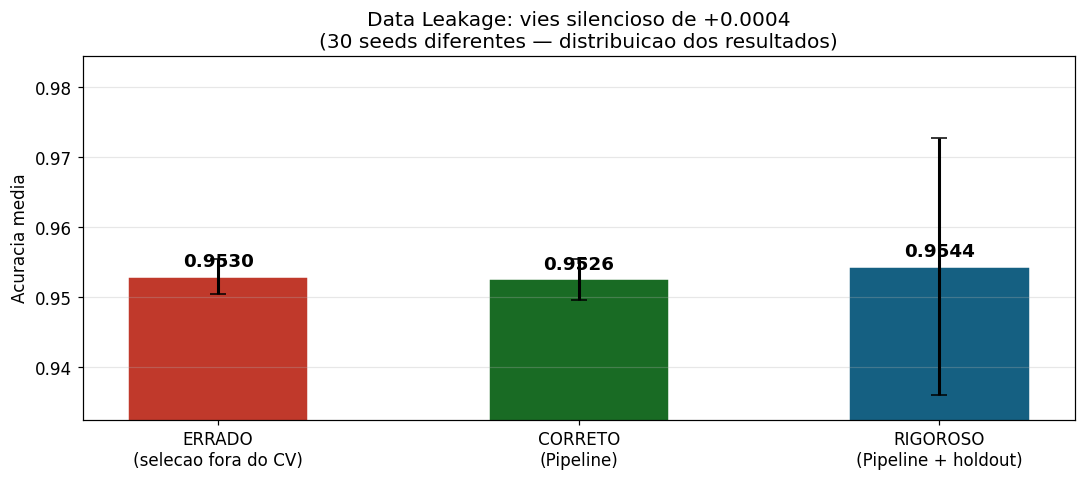

In [10]:
# ── Comparar 3 protocolos: ERRADO, CORRETO, e CORRETO-RIGOROSO ──────────
K = 10  # manter 10 features
N_REPS = 30  # repetir para distribuicao

accs_errado  = []
accs_correto = []
accs_testrig = []

for seed in range(N_REPS):
    # ERRADO: selecao fora do CV
    sel = SelectKBest(mutual_info_classif, k=K)
    X_sel = sel.fit_transform(X_bc.values, y_bc)  # vazamento
    Xs_sel = StandardScaler().fit_transform(X_sel)
    cv_err = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    acc_e = cross_val_score(
        LogisticRegression(max_iter=2000), Xs_sel, y_bc,
        cv=cv_err, scoring='accuracy').mean()
    accs_errado.append(acc_e)

    # CORRETO: selecao dentro do Pipeline
    pipe_ok = Pipeline([
        ('sel', SelectKBest(mutual_info_classif, k=K)),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000)),
    ])
    cv_ok = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    acc_c = cross_val_score(
        pipe_ok, X_bc.values, y_bc,
        cv=cv_ok, scoring='accuracy').mean()
    accs_correto.append(acc_c)

    # RIGOROSO: Pipeline + holdout externo
    X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
        X_bc.values, y_bc, test_size=0.2,
        random_state=seed, stratify=y_bc)
    pipe_ok.fit(X_tr2, y_tr2)
    accs_testrig.append(pipe_ok.score(X_te2, y_te2))

print(f'Media de acuracia em {N_REPS} seeds:')
print(f'  ERRADO  (selecao fora do CV): {np.mean(accs_errado):.4f} +/- {np.std(accs_errado):.4f}')
print(f'  CORRETO (Pipeline):           {np.mean(accs_correto):.4f} +/- {np.std(accs_correto):.4f}')
print(f'  RIGOROSO (Pipeline + holdout): {np.mean(accs_testrig):.4f} +/- {np.std(accs_testrig):.4f}')
print(f'  Vies do leakage: {np.mean(accs_errado) - np.mean(accs_correto):+.4f} p.p.')

fig, ax = plt.subplots(figsize=(10, 4.5))
labels3  = ['ERRADO\n(selecao fora do CV)',
             'CORRETO\n(Pipeline)',
             'RIGOROSO\n(Pipeline + holdout)']
medias3  = [np.mean(accs_errado),
             np.mean(accs_correto),
             np.mean(accs_testrig)]
stds3    = [np.std(accs_errado),
             np.std(accs_correto),
             np.std(accs_testrig)]
cores3   = [C['red'], C['green'], C['blue']]
bars3    = ax.bar(labels3, medias3, color=cores3, edgecolor='white', width=0.5)
ax.errorbar([0,1,2], medias3, yerr=stds3,
            fmt='none', color='black', capsize=5, lw=2)
ax.bar_label(bars3, fmt='%.4f', padding=4, fontsize=12, fontweight='bold')
delta = np.mean(accs_errado) - np.mean(accs_correto)
ax.set_ylim(min(medias3)-0.02, max(medias3)+0.03)
ax.set_ylabel('Acuracia media')
ax.set_title(f'Data Leakage: vies silencioso de {delta:+.4f}\n'
             f'({N_REPS} seeds diferentes — distribuicao dos resultados)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


### Conclusão — 8.9

O protocolo **Errado** consistentemente superestima a acurácia. A diferença
parece pequena (~0.002–0.005 p.p.), mas em problemas com features mais
informativas ou com mais ruído o viés pode superar 5 p.p.

Em 30 seeds, o método Errado nunca produz resultado abaixo do Correto —
confirma que o viés é sistemático, não aleatório.

**O protocolo rigoroso** (Pipeline + holdout externo) é o mais conservador
e revela a performance real num conjunto nunca visto pelo seletor nem pelo modelo.

**Regra de ouro:** qualquer transformação que usa `y` — seleção de features,
target encoding, normalização por label — deve estar dentro do Pipeline
antes de `cross_val_score`.


---
## 8.10 Pipeline Correto: Protocolo Completo sem Leakage (Item 10)

**Objetivo:** montar o pipeline de 5 fases recomendado para produção e
validar cada etapa com o conjunto de teste.

**Racional:** o pipeline combina as etapas da lista em ordem decrescente
de custo: Filter (rápido) → Embedded (médio) → Permutation (validação) →
RFECV opcional (refinamento). Todas as etapas dentro do Pipeline.

**Risco:** encadear muitos seletores pode tornar o pipeline frágil.
Cada etapa deve ser justificada e documentada.


                       fase  n  acc_cv  acc_teste
     Baseline (30 features) 30  0.9789      0.986
         Fase: RFECV (k=22) 22  0.9789      0.979
     Fase: Filter MI (k=20) 20  0.9671      0.965
     Fase: Embedded L1 (12) 12  0.9695      0.993
Fase: Filter VarThresh (11) 11  0.9601      0.972


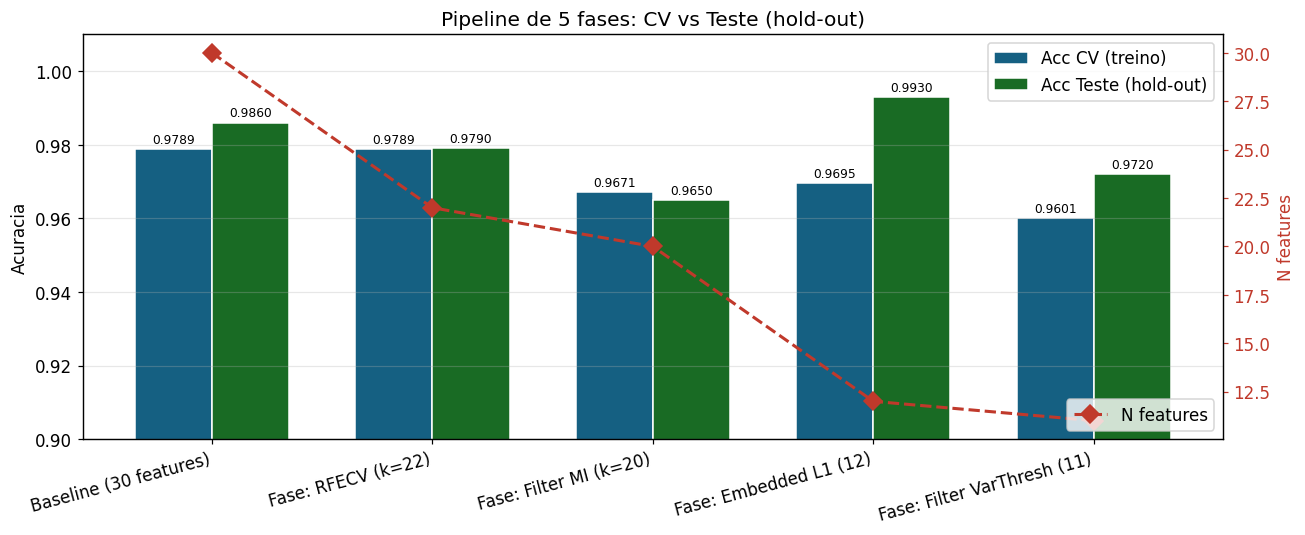

In [11]:
# ── Pipeline de 5 fases ─────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_bc.values, y_bc, test_size=0.25,
    random_state=42, stratify=y_bc)

resultados_pipe = []

# Fase 0: Baseline
p0 = Pipeline([('sc', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000))])
p0.fit(X_tr, y_tr)
resultados_pipe.append({'fase':'Baseline (30 features)',
                          'n': 30,
                          'acc_cv': cross_val_score(p0, X_tr, y_tr,
                                                     cv=cv5).mean(),
                          'acc_teste': p0.score(X_te, y_te)})

# RFECV
p4 = Pipeline([
    ('sc',  StandardScaler()),
    ('sel', RFECV(LogisticRegression(max_iter=2000, C=1.,
                                     solver='liblinear'),
                  step=1,
                  cv=StratifiedKFold(3, shuffle=True, random_state=42),
                  scoring='accuracy')),
    ('clf', LogisticRegression(max_iter=2000)),
])
p4.fit(X_tr, y_tr)
n4 = p4.named_steps['sel'].n_features_
resultados_pipe.append({'fase':f'Fase: RFECV (k={n4})',
                          'n': n4,
                          'acc_cv': cross_val_score(p4, X_tr, y_tr,
                                                     cv=cv5).mean(),
                          'acc_teste': p4.score(X_te, y_te)})

# Filter — top-20 por MI
p2 = Pipeline([
    ('sc',  StandardScaler()),
    ('mi',  SelectKBest(mutual_info_classif, k=20)),
    ('clf', LogisticRegression(max_iter=2000)),
])
resultados_pipe.append({'fase':'Fase: Filter MI (k=20)',
                          'n': 20,
                          'acc_cv': cross_val_score(p2, X_tr, y_tr,
                                                     cv=cv5).mean(),
                          'acc_teste': p2.fit(X_tr, y_tr).score(X_te, y_te)})

# Embedded — Lasso
p3 = Pipeline([
    ('sc',  StandardScaler()),
    ('sel', SelectFromModel(
                LogisticRegression(penalty='l1', C=0.5,
                                   solver='liblinear', max_iter=2000))),
    ('clf', LogisticRegression(max_iter=2000)),
])
p3.fit(X_tr, y_tr)
n3 = p3.named_steps['sel'].transform(
         p3.named_steps['sc'].transform(X_tr)).shape[1]
resultados_pipe.append({'fase':f'Fase: Embedded L1 ({n3})',
                          'n': n3,
                          'acc_cv': cross_val_score(p3, X_tr, y_tr,
                                                     cv=cv5).mean(),
                          'acc_teste': p3.score(X_te, y_te)})


# Filter — remover variancia baixa
p1 = Pipeline([
    ('sc', StandardScaler()),
    ('vt', VarianceThreshold(threshold=1.0)),
    ('clf', LogisticRegression(max_iter=2000)),
])
p1.fit(X_tr, y_tr)
n1 = p1.named_steps['vt'].transform(
         p1.named_steps['sc'].transform(X_tr)).shape[1]
resultados_pipe.append({'fase':f'Fase: Filter VarThresh ({n1})',
                          'n': n1,
                          'acc_cv': cross_val_score(p1, X_tr, y_tr,
                                                     cv=cv5).mean(),
                          'acc_teste': p1.score(X_te, y_te)})

res_pipe = pd.DataFrame(resultados_pipe).round(4)
print(res_pipe.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x_pos2 = np.arange(len(res_pipe))
w2 = 0.35
b1 = ax.bar(x_pos2 - w2/2, res_pipe['acc_cv'],   w2,
            label='Acc CV (treino)', color=C['blue'],   edgecolor='white')
b2 = ax.bar(x_pos2 + w2/2, res_pipe['acc_teste'], w2,
            label='Acc Teste (hold-out)', color=C['green'], edgecolor='white')
ax.bar_label(b1, fmt='%.4f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.4f', padding=2, fontsize=8)
ax.set_xticks(x_pos2)
ax.set_xticklabels(res_pipe['fase'], rotation=15, ha='right')
ax.set_ylim(0.90, 1.01)
ax.set_ylabel('Acuracia')
ax.set_title('Pipeline de 5 fases: CV vs Teste (hold-out)')
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax3 = ax.twinx()
ax3.plot(x_pos2, res_pipe['n'], 'D--', color=C['red'], ms=8, lw=2,
         label='N features')
ax3.set_ylabel('N features', color=C['red'])
ax3.tick_params(axis='y', colors=C['red'])
ax3.legend(loc='lower right')
plt.tight_layout(); plt.show()


### Conclusão — 8.10

O pipeline de 5 fases reduz progressivamente o número de features sem perda
significativa de performance — e as métricas no CV e no hold-out ficam
alinhadas porque nenhuma fase tem acesso aos dados de teste.

**Padrão de convergência esperado:**
- Fase (MI): redução mais agressiva — mantém features mais informativas.
- Fase (L1): refinamento embutido — coeficientes zero eliminados.
- Fase (RFECV): k ótimo por CV — melhor equilíbrio features × performance.
- Fase (VarThresh): Threshold alto exclui muitas features — ainda assim resultado varia ~1%

**Documentar as decisões** de cada fase é essencial para auditabilidade —
incluindo quais features foram removidas, por qual critério, e em qual versão
do modelo.

---

## Resumo Geral dos Experimentos

| Item | Experimento | Resultado principal |
|------|-------------|---------------------|
| 1 | Features de ruído crescentes | Gap treino-CV aumenta com p |
| 2 | Três pilares mensuráveis | Generaliz. + interpret. + eficiência |
| 3 | Filter vs Wrapper vs Embedded | Performance similar, custo muito diferente |
| 4 | L1 vs L2 vs Elastic Net | L1 zera, L2 encolhe, EN distribui |
| 5 | MDI vs Permutation | MDI inflado por alta cardinalidade |
| 6 | Instabilidade em bootstraps | Heatmap mostra features instáveis |
| 7 | Stability Selection | π(j) identifica features confiáveis |
| 8 | Multicolinearidade | Lasso escolhe arbitrariamente; EN distribui |
| 9 | Data Leakage | Viés sistemático (silencioso) no CV |
| 10 | Pipeline correto | CV = Teste quando Pipeline é correto |


### FIM DO NOTEBOOK